In [2]:
import os
import time
import math

import io
import cv2
import numpy as np
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

from app.routers.soyanalysis import *

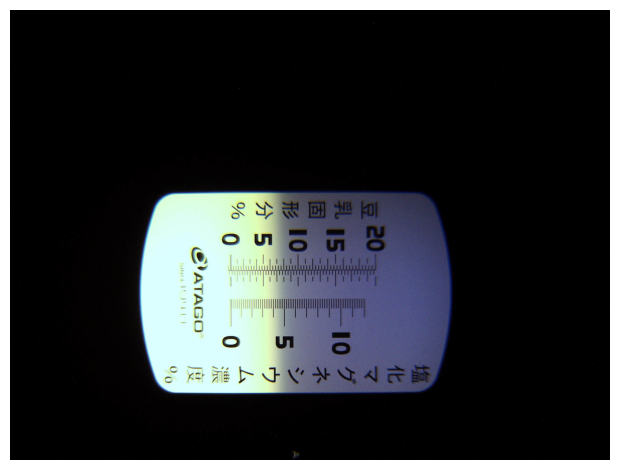

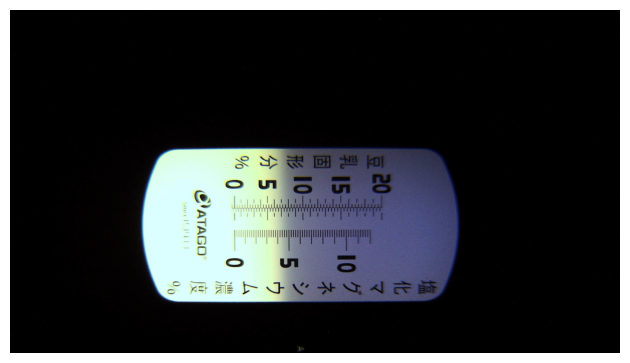

In [26]:
image = cv2.imread('images/figure.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
resized_image = cv2.resize(image, (1920, 1080))

plt.imshow(image)
plt.axis('off')
plt.tight_layout()
plt.show()

plt.imshow(resized_image)
plt.axis('off')
plt.tight_layout()
plt.show()

No lines detected


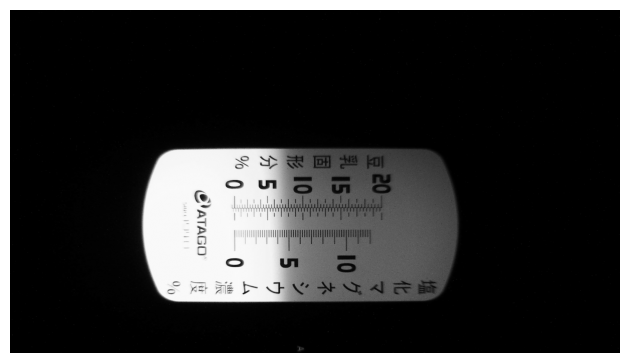

In [ ]:
gray_image = cv2.cvtColor(resized_image, cv2.COLOR_RGB2GRAY)
average_angle, rot_image = rotate_image(gray_image)

plt.imshow(rot_image, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

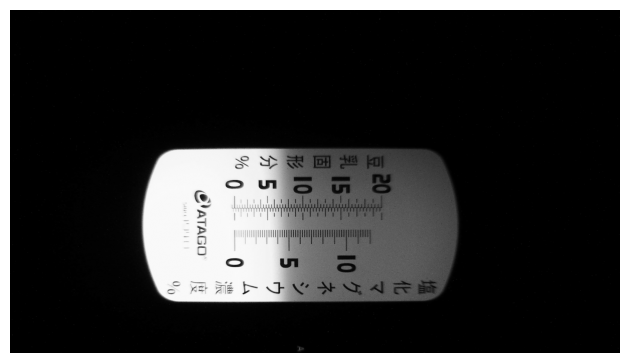

In [31]:
plt.imshow(gray_image, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

{'top': 437, 'bottom': 919, 'left': 418, 'right': 1387}


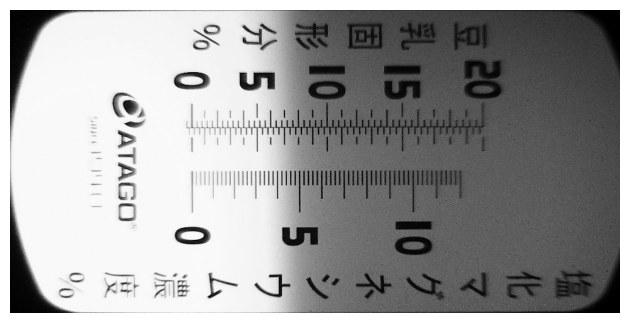

In [36]:
cropped_result, cropped_image = find_edges_line(gray_image, 30000, 20000)

plt.imshow(cropped_image, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

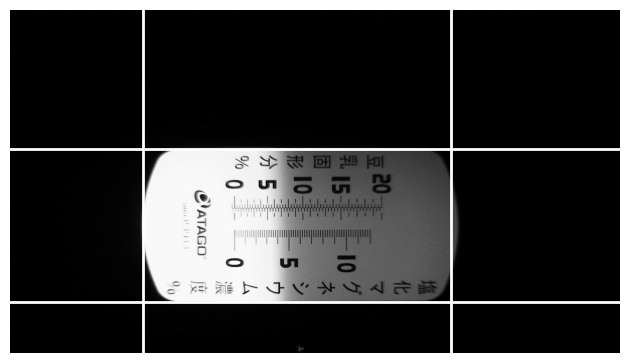

In [44]:
plt.imshow(gray_image, cmap='gray')
plt.axis('off')

# 상단/하단
plt.axhline(cropped_result['top'], color='white', linestyle='-', linewidth=2, label='Top')
plt.axhline(cropped_result['bottom'], color='white', linestyle='-', linewidth=2, label='Bottom')
# 좌측/우측
plt.axvline(cropped_result['left'], color='white', linewidth=2, label='Left')
plt.axvline(cropped_result['right'], color='white', linestyle='-', linewidth=2, label='Right')

plt.tight_layout()
plt.show()

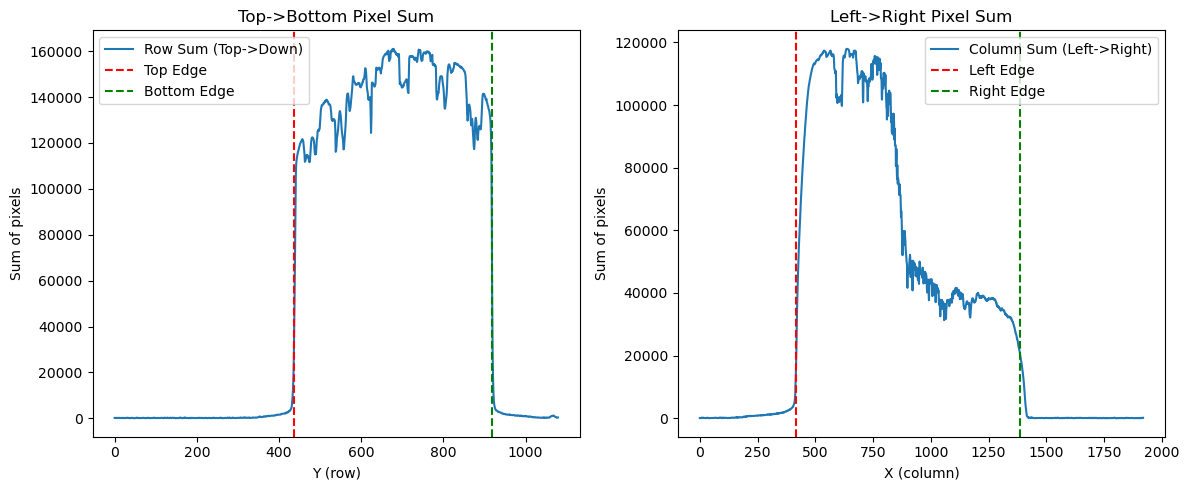

In [37]:
img = gray_image.copy()
h, w = img.shape

sum_top_down = [np.sum(img[y, :]) for y in range(h)]
sum_left_right = [np.sum(img[:, x]) for x in range(w)]

# 상->하 그래프
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(h), sum_top_down, label='Row Sum (Top->Down)')
plt.axvline(cropped_result['top'], color='r', linestyle='--', label='Top Edge')
plt.axvline(cropped_result['bottom'], color='g', linestyle='--', label='Bottom Edge')
plt.xlabel('Y (row)')
plt.ylabel('Sum of pixels')
plt.title('Top->Bottom Pixel Sum')
plt.legend()

# 좌->우 그래프
plt.subplot(1, 2, 2)
plt.plot(range(w), sum_left_right, label='Column Sum (Left->Right)')
plt.axvline(cropped_result['left'], color='r', linestyle='--', label='Left Edge')
plt.axvline(cropped_result['right'], color='g', linestyle='--', label='Right Edge')
plt.xlabel('X (column)')
plt.ylabel('Sum of pixels')
plt.title('Left->Right Pixel Sum')
plt.legend()

plt.tight_layout()
plt.show()

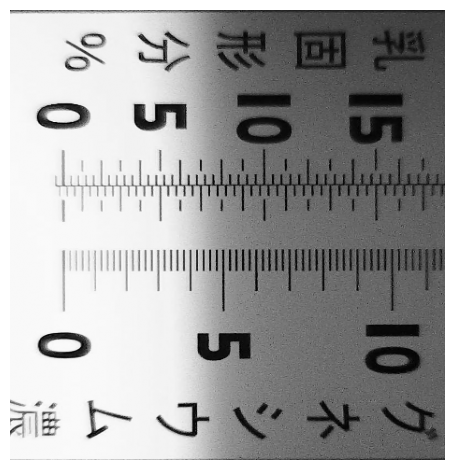

In [30]:
left_crop_ratio = 0.24
right_crop_ratio = 0.72
analysis_image = cropped_image[:, int(cropped_image.shape[1]*left_crop_ratio):int(cropped_image.shape[1]*right_crop_ratio)]

plt.imshow(analysis_image, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

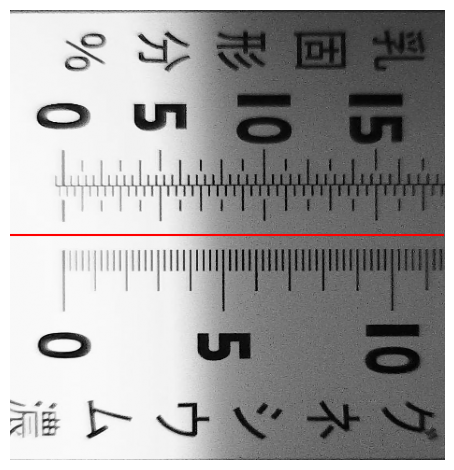

In [58]:
plt.imshow(analysis_image, cmap='gray')
plt.axhline(analysis_image.shape[0] // 2, color='r')
plt.axis('off')
plt.tight_layout()
plt.show()

analysis_image shape: (482, 465)
min_index: 207 / min_value: -1.3856108182978062
min_value2_index: 168 / min_value2: -0.6928054091489031
width: 39
peaks: [39]


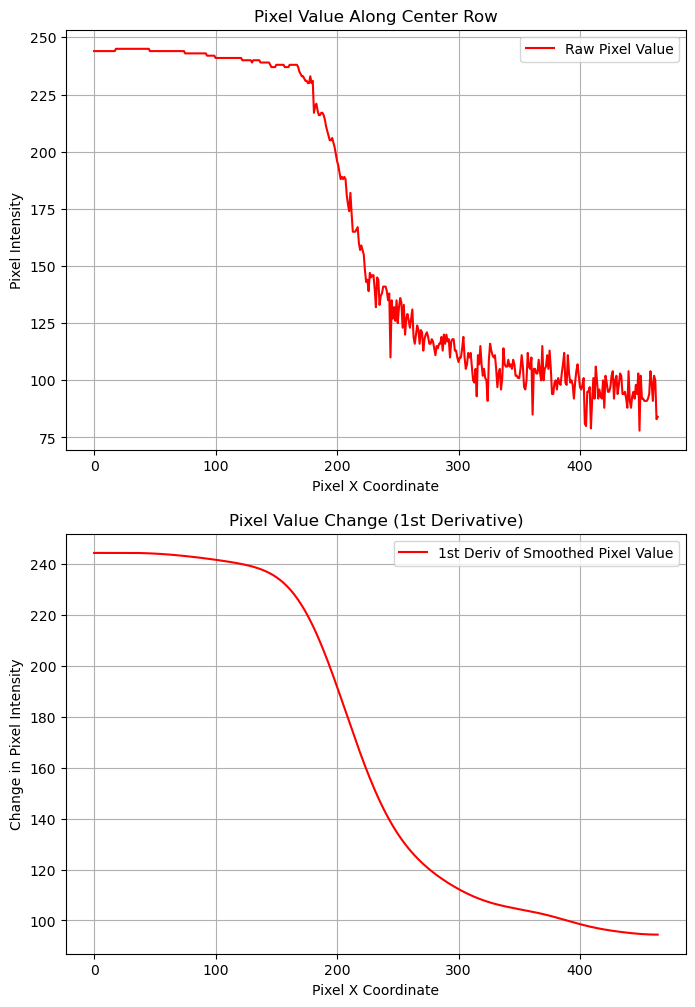

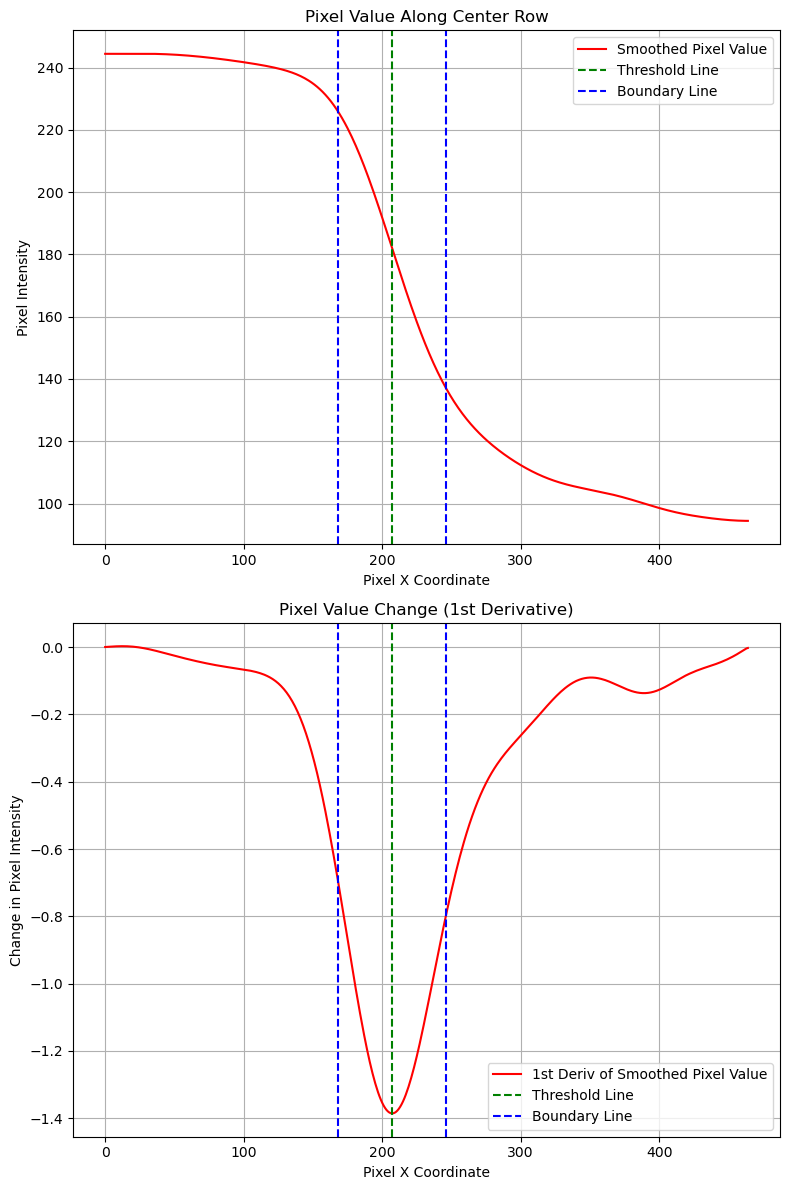

In [56]:
print("analysis_image shape:", analysis_image.shape)
y_raw = analysis_image[analysis_image.shape[0] // 2, :]
x = np.arange(len(y_raw))

y_smooth = gaussian_filter1d(y_raw.astype(float), sigma=24)
y_deriv = np.gradient(y_smooth)

# ---------------------------------

min_index = np.argmin(y_deriv)
min_value = y_deriv[min_index]
min_value2 = min_value / 2
min_value2_index = min_index
while min_value2_index > 0:
    if y_deriv[min_value2_index] >= min_value2:
        break
    min_value2_index -= 1
width = min_index - min_value2_index
print("min_index:", min_index, "/ min_value:", min_value)
print("min_value2_index:", min_value2_index, "/ min_value2:", min_value2)
print("width:", width)

region = y_deriv[min_value2_index:min_index+width]
peaks, _ = find_peaks(-region, prominence=abs(min_value)*0.2)
print("peaks:", peaks)

if len(peaks) > 1:
    raise HTTPException(status_code=400, detail="더블 딥(double dip) 현상 감지됨 - 측정 불가")

fig, axs = plt.subplots(2, 1, figsize=(8, 12))

# 1) 픽셀값 변화 그래프
axs[0].plot(x, y_raw, color='red', label='Raw Pixel Value')
axs[0].set_title('Pixel Value Along Center Row')
axs[0].set_xlabel('Pixel X Coordinate')
axs[0].set_ylabel('Pixel Intensity')
axs[0].legend()
axs[0].grid(True)

# 2) 픽셀값 변화량(1차 미분) 그래프
axs[1].plot(x, y_smooth, color='red', label='1st Deriv of Smoothed Pixel Value')
axs[1].set_title('Pixel Value Change (1st Derivative)')
axs[1].set_xlabel('Pixel X Coordinate')
axs[1].set_ylabel('Change in Pixel Intensity')
axs[1].legend()
axs[1].grid(True)


fig, axs = plt.subplots(2, 1, figsize=(8, 12))

# 1) 픽셀값 변화 그래프
axs[0].plot(x, y_smooth, color='red', label='Smoothed Pixel Value')
axs[0].axvline(min_index, color='green', linestyle='--', label='Threshold Line')
axs[0].axvline(min_value2_index, color='blue', linestyle='--', label='Boundary Line')
axs[0].axvline(min_index + width, color='blue', linestyle='--')
axs[0].set_title('Pixel Value Along Center Row')
axs[0].set_xlabel('Pixel X Coordinate')
axs[0].set_ylabel('Pixel Intensity')
axs[0].legend()
axs[0].grid(True)

# 2) 픽셀값 변화량(1차 미분) 그래프
axs[1].plot(x, y_deriv, color='red', label='1st Deriv of Smoothed Pixel Value')
axs[1].axvline(min_index, color='green', linestyle='--', label='Threshold Line')
axs[1].axvline(min_value2_index, color='blue', linestyle='--', label='Boundary Line')
axs[1].axvline(min_index + width, color='blue', linestyle='--')
axs[1].set_title('Pixel Value Change (1st Derivative)')
axs[1].set_xlabel('Pixel X Coordinate')
axs[1].set_ylabel('Change in Pixel Intensity')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

analysis_image shape: (482, 465)
min_index: 207 / min_value: -1.3856108182978062
left_half_idx: 168 / right_half_idx: 252
width: 84
peaks: [39]


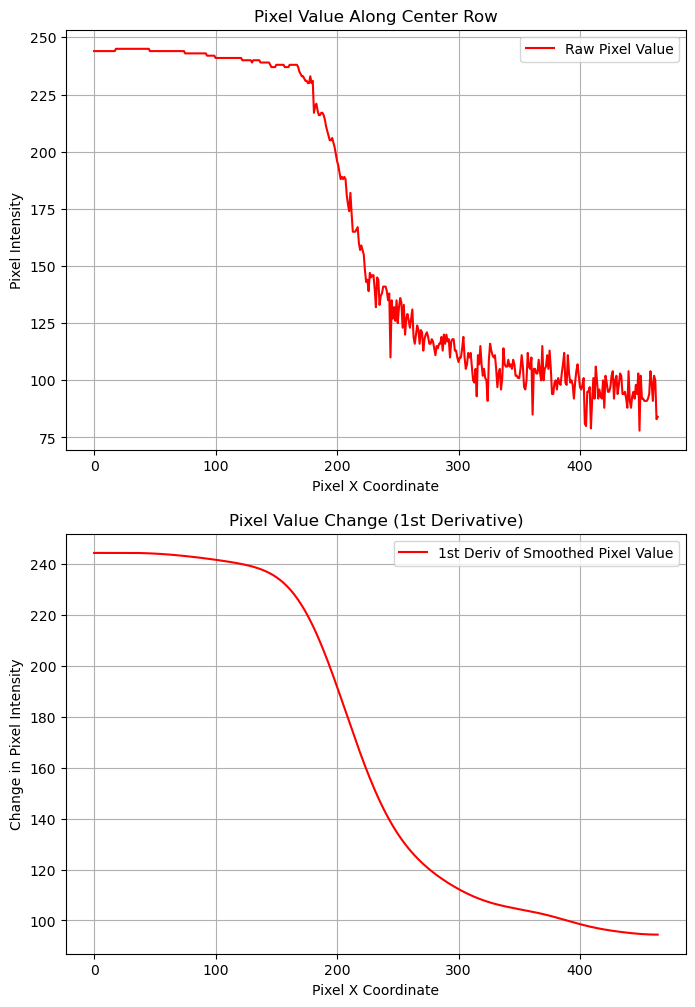

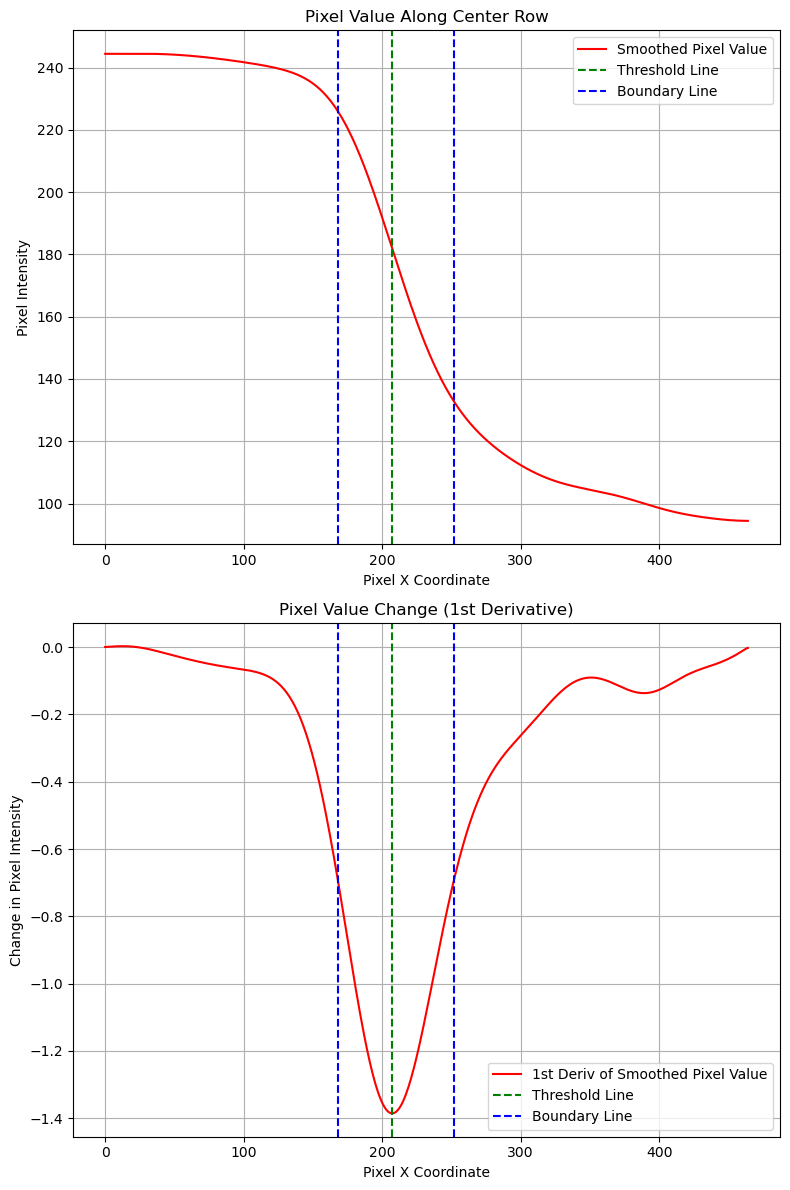

In [62]:
print("analysis_image shape:", analysis_image.shape)
y_raw = analysis_image[analysis_image.shape[0] // 2, :]
x = np.arange(len(y_raw))

y_smooth = gaussian_filter1d(y_raw.astype(float), sigma=24)
y_deriv = np.gradient(y_smooth)

# ---------------------------------

min_index = np.argmin(y_deriv)
min_value = y_deriv[min_index]
half_val = min_value / 2.0

left_half_idx = None
i = min_index
while i > 0:
    if y_deriv[i] >= half_val:
        left_half_idx = i
        break
    i -= 1
right_half_idx = None
i = min_index
n = len(y_deriv)
while i < n-1:
    if y_deriv[i] >= half_val:
        right_half_idx = i
        break
    i += 1

width = right_half_idx - left_half_idx

print("min_index:", min_index, "/ min_value:", min_value)
print("left_half_idx:", left_half_idx, "/ right_half_idx:", right_half_idx)
print("width:", width)

region = y_deriv[left_half_idx:right_half_idx]
peaks, _ = find_peaks(-region, prominence=abs(min_value)*0.2)
print("peaks:", peaks)

if len(peaks) > 1:
    raise HTTPException(status_code=400, detail="더블 딥(double dip) 현상 감지됨 - 측정 불가")

fig, axs = plt.subplots(2, 1, figsize=(8, 12))

# 1) 픽셀값 변화 그래프
axs[0].plot(x, y_raw, color='red', label='Raw Pixel Value')
axs[0].set_title('Pixel Value Along Center Row')
axs[0].set_xlabel('Pixel X Coordinate')
axs[0].set_ylabel('Pixel Intensity')
axs[0].legend()
axs[0].grid(True)

# 2) 픽셀값 변화량(1차 미분) 그래프
axs[1].plot(x, y_smooth, color='red', label='1st Deriv of Smoothed Pixel Value')
axs[1].set_title('Pixel Value Change (1st Derivative)')
axs[1].set_xlabel('Pixel X Coordinate')
axs[1].set_ylabel('Change in Pixel Intensity')
axs[1].legend()
axs[1].grid(True)


fig, axs = plt.subplots(2, 1, figsize=(8, 12))

# 1) 픽셀값 변화 그래프
axs[0].plot(x, y_smooth, color='red', label='Smoothed Pixel Value')
axs[0].axvline(min_index, color='green', linestyle='--', label='Threshold Line')
axs[0].axvline(left_half_idx, color='blue', linestyle='--', label='Boundary Line')
axs[0].axvline(right_half_idx, color='blue', linestyle='--')
axs[0].set_title('Pixel Value Along Center Row')
axs[0].set_xlabel('Pixel X Coordinate')
axs[0].set_ylabel('Pixel Intensity')
axs[0].legend()
axs[0].grid(True)

# 2) 픽셀값 변화량(1차 미분) 그래프
axs[1].plot(x, y_deriv, color='red', label='1st Deriv of Smoothed Pixel Value')
axs[1].axvline(min_index, color='green', linestyle='--', label='Threshold Line')
axs[1].axvline(left_half_idx, color='blue', linestyle='--', label='Boundary Line')
axs[1].axvline(right_half_idx, color='blue', linestyle='--')
axs[1].set_title('Pixel Value Change (1st Derivative)')
axs[1].set_xlabel('Pixel X Coordinate')
axs[1].set_ylabel('Change in Pixel Intensity')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

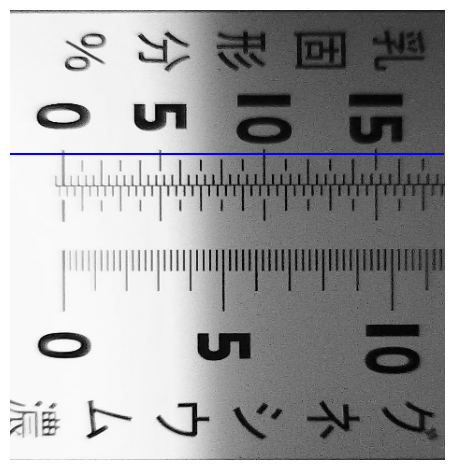

In [60]:
plt.imshow(analysis_image, cmap='gray')
plt.axhline(int(analysis_image.shape[0] * 0.32), color='b')
plt.axis('off')
plt.tight_layout()
plt.show()

left_crop_image shape: (482, 465)
marks: [np.int64(56), np.int64(160), np.int64(271), np.int64(391)]


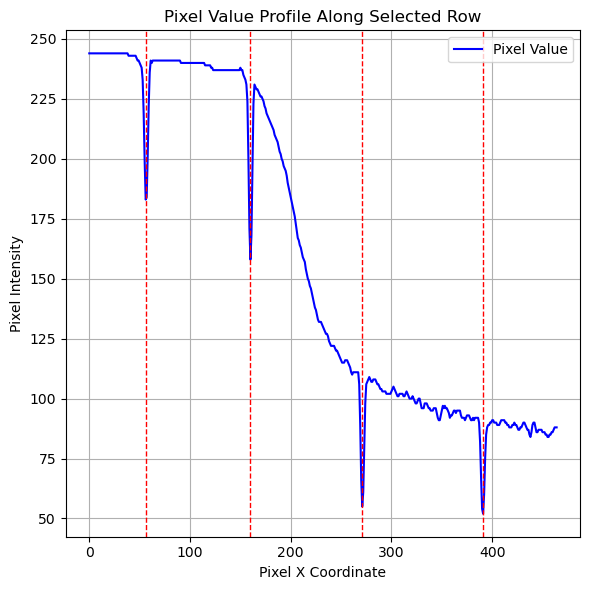

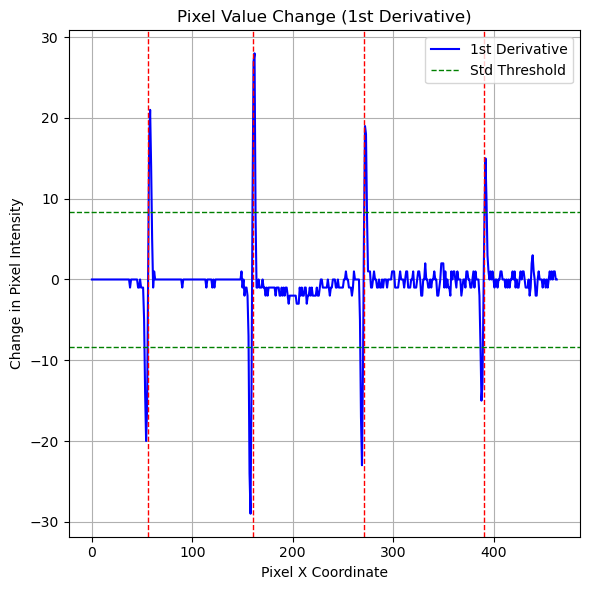

In [78]:
anal_blur = cv2.GaussianBlur(analysis_image, (5, 5), 1.5)
h, w = anal_blur.shape 
print("left_crop_image shape:", anal_blur.shape)

pixel_data = anal_blur[int(h*0.32), :].astype(np.int16)
pixel_deriv = np.diff(pixel_data, n=1)
std_threshold = np.std(pixel_deriv) * 2

marks = []
idx = 0
search_radius = 10

while idx < len(pixel_deriv):
    if abs(pixel_deriv[idx]) > std_threshold:
        start = max(0, idx - search_radius)
        end = min(len(pixel_data), idx + search_radius)

        local_min_idx = np.argmin(pixel_data[start:end]) + start
        marks.append(local_min_idx)
        idx += 100
    else:
        idx += 1

print("marks:", marks)

x = np.arange(len(pixel_data))

raw_pixel_data = analysis_image[int(h*0.32), :].astype(np.int16)
raw_pixel_deriv = np.diff(raw_pixel_data, n=1) 

# plt.figure(figsize=(7, 6))
# plt.plot(x, raw_pixel_data, color='b', label='Pixel Value')
# for m in marks:
#     plt.axvline(m, color='r', linestyle='--', linewidth=1.0)
# plt.title('Pixel Value Profile Along Selected Row')
# plt.xlabel('Pixel X Coordinate')
# plt.ylabel('Pixel Intensity')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(7, 6))
# plt.plot(x[:-1], raw_pixel_deriv, color='b', label='Pixel Value')
# for m in marks:
#     plt.axvline(m, color='r', linestyle='--', linewidth=1.0)
# plt.title('Pixel Value Profile Along Selected Row')
# plt.xlabel('Pixel X Coordinate')
# plt.ylabel('Pixel Intensity')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

plt.figure(figsize=(6, 6))
plt.plot(x, pixel_data, color='b', label='Pixel Value')
for m in marks:
    plt.axvline(m, color='r', linestyle='--', linewidth=1.0)
plt.title('Pixel Value Profile Along Selected Row')
plt.xlabel('Pixel X Coordinate')
plt.ylabel('Pixel Intensity')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.plot(x[:-1], pixel_deriv, color='b', label='1st Derivative')
for m in marks:
    plt.axvline(m, color='r', linestyle='--', linewidth=1.0)
plt.axhline(std_threshold, color='g', linestyle='--', linewidth=1.0, label='Std Threshold')
plt.axhline(-std_threshold, color='g', linestyle='--', linewidth=1.0)
plt.title('Pixel Value Change (1st Derivative)')
plt.xlabel('Pixel X Coordinate')
plt.ylabel('Change in Pixel Intensity')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 경진대회 이미지

{'top': 437, 'bottom': 919, 'left': 416, 'right': 1384}


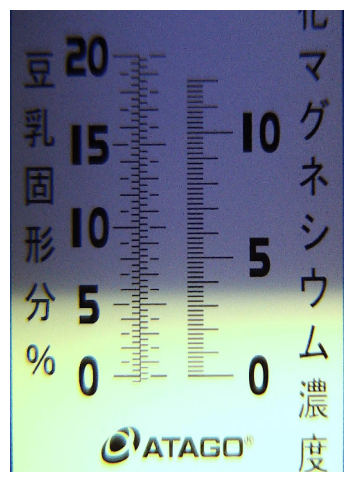

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Load image with relative path
# img_path = r'images\mk2\soyimage_mk2\image\6\3\WIN_20251002_17_56_58_Pro.jpg'
img_path = r'images\mk2\soyimage_mk2\image\7\3\WIN_20251002_18_03_29_Pro.jpg'
# img_path = r'images\mk2\soyimage_mk2\image\8\3\WIN_20251002_18_07_37_Pro.jpg'
img = cv2.imread(img_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
resi_img = cv2.resize(img_rgb, (1920, 1080))
line_results, line_cropped_image = find_edges_line(cv2.cvtColor(resi_img, cv2.COLOR_RGB2GRAY), 30000, 20000)
crop_img = resi_img[line_results['top']:line_results['bottom'], line_results['left']+150:line_results['right']-150]
crop_img_rota = cv2.rotate(crop_img, cv2.ROTATE_90_COUNTERCLOCKWISE)

# Show with matplotlib
plt.figure(figsize=(6, 6))
plt.imshow(crop_img_rota)
plt.axis("off")
plt.show()